Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, KFold

Import Dataset

In [2]:
df = pd.read_csv("data.csv", delimiter='\t', low_memory=False)
df.head()

,Unnamed: 0,date,id,size_grp,age,aliq_at,aliq_mat,ami_126d,at_be,at_gr1,...,turnover_var_126d,z_score,zero_trades_126d,zero_trades_21d,zero_trades_252d,ret,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
0,53170,9/30/1962,33814,mega,-0.4108911,0.3436155,0.0,-0.290922,-0.44744524,0.24796748,...,0.27476254,0.0,0.17842606,0.033875,0.0,0.017612524,NaN,NaN,NaN,NaN
1,53907,10/31/1962,33814,mega,-0.41374046,0.33333334,0.0,-0.281893,-0.44759825,0.23134328,...,0.21059783,0.0,0.13586956,0.094301,0.0,0.1242307722568512,NaN,NaN,NaN,NaN
2,54659,11/30/1962,33814,mega,-0.4017857,0.33169705,0.0,-0.297587,-0.4487909,0.2214854,...,0.1679947,0.0,0.1374502,0.111406,0.0,-0.01208981,NaN,NaN,NaN,NaN
3,55425,12/31/1962,33814,mega,-0.37068966,0.32225236,0.0,-0.309585,-0.4398085,0.21501926,...,0.12516046,0.0,0.1097561,0.194480,0.11369509,0.087412588,NaN,NaN,NaN,NaN
4,56207,1/31/1963,33814,mega,-0.36795145,0.32456142,0.0,-0.308729,-0.44189188,0.21082802,...,0.035714287,0.0,0.10841837,0.149682,0.08151476,-0.021864953,NaN,NaN,NaN,NaN


Clean Dataset

In [3]:
df.drop(columns=['Unnamed: 126', 'Unnamed: 127', 'Unnamed: 128', 'Unnamed: 129'], inplace=True)
df = df.iloc[:-2, :]
df = df.drop(index=range(122974, 122978))
df.drop(columns=['size_grp'], inplace=True)
df.dropna(inplace=True)
date = df['date']
print(date.shape)
df.drop(columns=['date'], inplace=True)

df.dropna(inplace=True)
print(df.shape)

(122634,)
(122634, 124)


Export Dataset back 

In [4]:
df.to_csv("cleaned_data.csv", index=False)
date.to_csv("cleaned_date.csv", index=False)

Lasso regression using Sklearn

Lasso Regression MSE (alpha=1.0): 0.0104


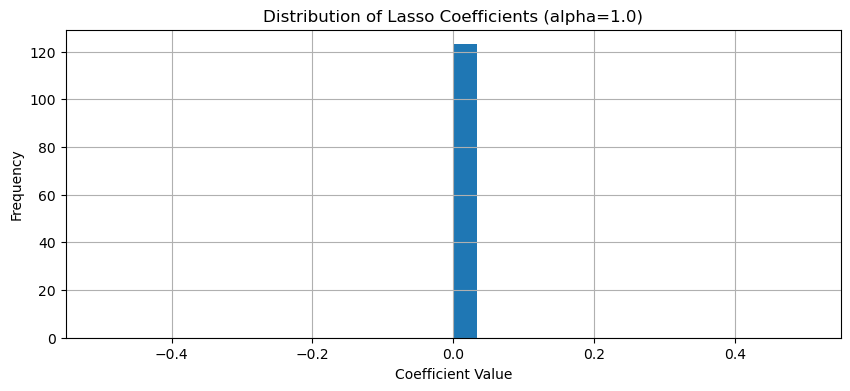

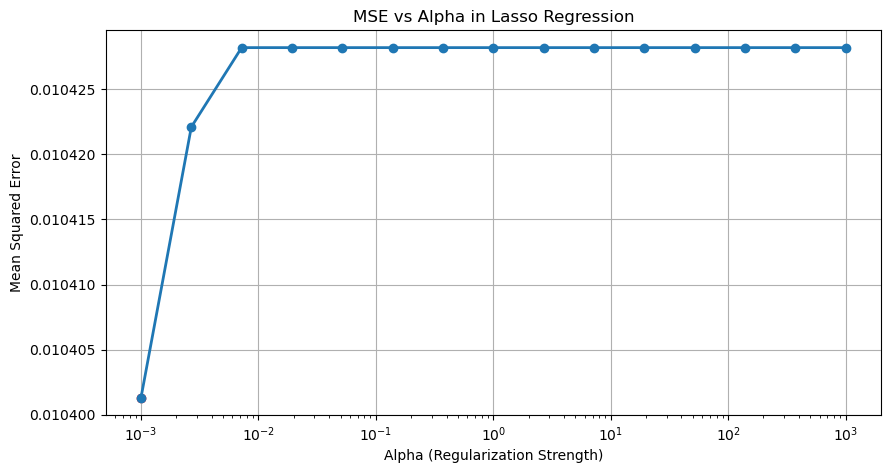

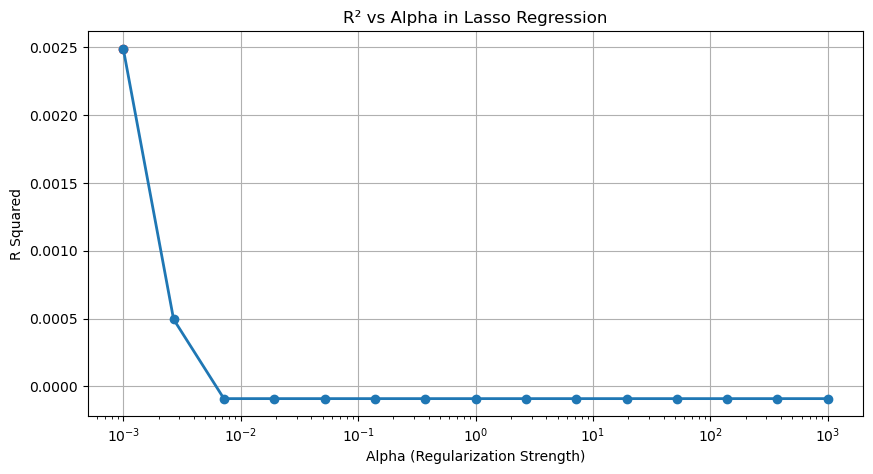

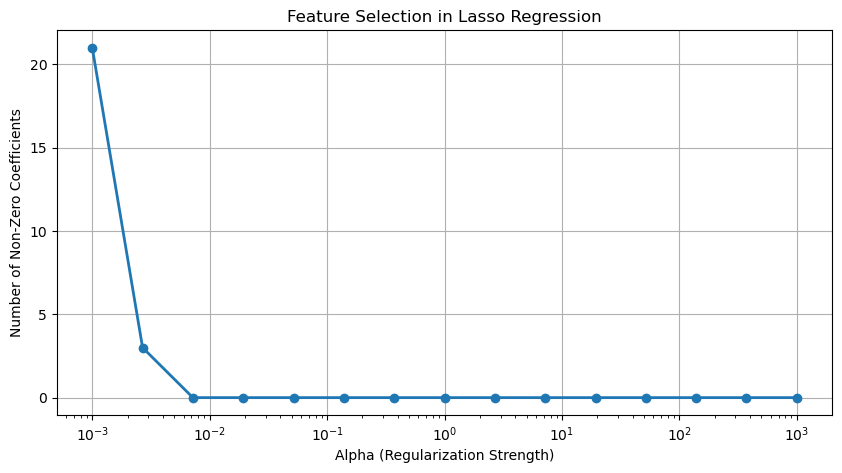

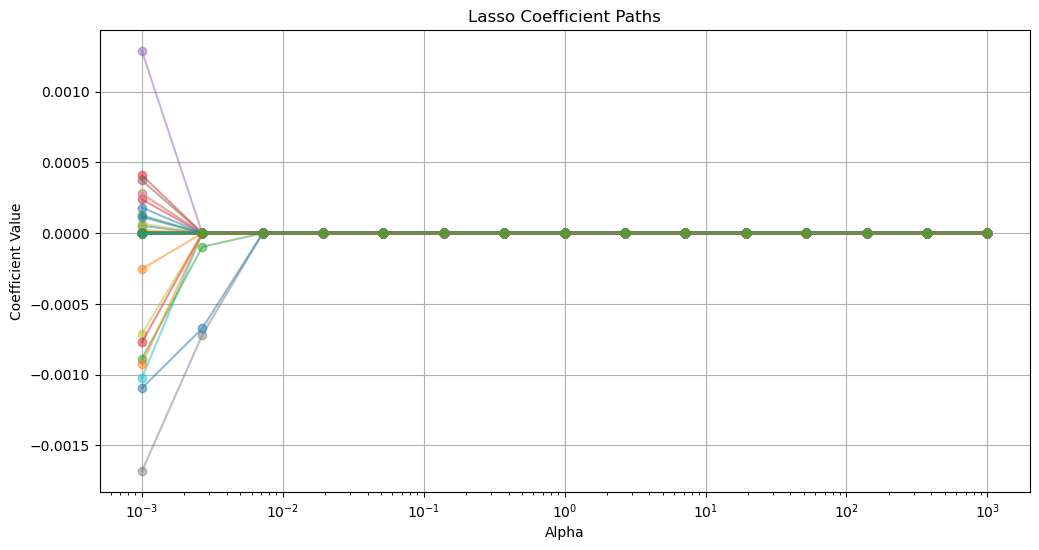

In [5]:
X_unscaled = df.drop(columns='ret')
X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)
y = df['ret']
y = y.apply(pd.to_numeric, errors='coerce')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Lasso regression with alpha=1.0
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train, y_train)
y_pred = lasso.predict(X_test)

# Compute and print MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Lasso Regression MSE (alpha=1.0): {mse:.4f}")

# Plot distribution of coefficients
plt.figure(figsize=(10, 4))
plt.hist(lasso.coef_, bins=30)
plt.title("Distribution of Lasso Coefficients (alpha=1.0)")
plt.xlabel("Coefficient Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# Analyze effect of varying alpha
alphas = np.logspace(-3, 3, 15)
coefs = []
mses = []
rs = []
nonzero_coefs = []  # Track number of non-zero coefficients

for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)
    coefs.append(model.coef_)
    y_pred = model.predict(X_test)
    mses.append(mean_squared_error(y_test, y_pred))
    rs.append(r2_score(y_test, y_pred))
    nonzero_coefs.append(np.sum(model.coef_ != 0))  # Count non-zero coefficients

best_idx_ms = np.argmin(mses)
best_idx_rs = np.argmax(rs)  # Note: For R², we want maximum, not minimum
best_alpha_ms = alphas[best_idx_ms]
best_mse = mses[best_idx_ms]
best_alpha_rs = alphas[best_idx_rs]
best_rs = rs[best_idx_rs]

def plot(losses, best_loss, name_loss, abbrev, best_alpha, alphas):
    plt.figure(figsize=(10, 5))
    plt.plot(alphas, losses, marker='o', linewidth=2)
    plt.xscale("log")
    plt.xlabel("Alpha (Regularization Strength)")
    plt.ylabel(name_loss)
    plt.title(abbrev + " vs Alpha in Lasso Regression")
    plt.grid(True)
    # Turn off scientific notation
    plt.ticklabel_format(style='plain', axis='y')
    
    # Annotate best point
    plt.scatter(best_alpha, best_loss, color='red')
    
    plt.show()

plot(mses, best_mse, 'Mean Squared Error', 'MSE', best_alpha_ms, alphas)
plot(rs, best_rs, 'R Squared', 'R²', best_alpha_rs, alphas)

# Additional plot for feature selection behavior
plt.figure(figsize=(10, 5))
plt.plot(alphas, nonzero_coefs, marker='o', linewidth=2)
plt.xscale("log")
plt.xlabel("Alpha (Regularization Strength)")
plt.ylabel("Number of Non-Zero Coefficients")
plt.title("Feature Selection in Lasso Regression")
plt.grid(True)
plt.show()

# Plot coefficient paths
plt.figure(figsize=(12, 6))
for i in range(len(coefs[0])):
    plt.plot(alphas, [coefs[j][i] for j in range(len(alphas))], 'o-', alpha=0.5)
plt.xscale('log')
plt.xlabel('Alpha')
plt.ylabel('Coefficient Value')
plt.title('Lasso Coefficient Paths')
plt.grid(True)
plt.show()

Now compare with a manual Lasso regression

In [6]:
def lasso_reg(X, y, alpha, max_iter=1000, tol=1e-4):
    """
    Lasso Regression Implementation using coordinate descent
    
    Parameters:
    -----------
    X : array-like, shape (n_samples, n_features)
        Training data
    y : array-like, shape (n_samples,)
        Target values
    alpha : float
        Regularization strength (L1 penalty)
    max_iter : int, default=1000
        Maximum number of iterations
    tol : float, default=1e-4
        Tolerance for stopping criterion
        
    Returns:
    --------
    w : array, shape (n_features,)
        Coefficients
    """
    # Convert inputs to numpy arrays if they aren't already
    X = np.asarray(X)
    y = np.asarray(y)
    
    n_samples, n_features = X.shape
    
    # Initialize weights
    w = np.zeros(n_features)
    
    # Precompute X^T
    X_T = X.T
    
    # Precompute X^T * y
    Xy = np.dot(X_T, y)
    
    # Precompute X^T * X diagonal (for faster updates)
    X_squared = np.sum(X * X, axis=0)
    
    # Initialize prediction
    y_pred = np.zeros(n_samples)
    
    # Coordinate descent
    for iteration in range(max_iter):
        w_old = w.copy()
        
        # Update each coordinate
        for j in range(n_features):
            if X_squared[j] == 0:
                continue
                
            # Remove the contribution of feature j from the prediction
            y_pred -= w[j] * X[:, j]
            
            # Calculate the residual correlation
            r_j = Xy[j] - np.dot(X_T[j], y_pred)
            
            # Soft thresholding
            if r_j > alpha:
                w[j] = (r_j - alpha) / X_squared[j]
            elif r_j < -alpha:
                w[j] = (r_j + alpha) / X_squared[j]
            else:
                w[j] = 0
            
            # Update the prediction with the new weight
            y_pred += w[j] * X[:, j]
        
        # Check convergence
        if np.sum((w - w_old) ** 2) < tol:
            break
    
    return w


Predictors Function

In [7]:
def lasso_alphas_predictors(X_train, X_test, y_train, y_test):
    """
    Evaluate Lasso regression with different feature subsets and regularization parameters
    
    Parameters:
    -----------
    X_train : DataFrame
        Training features
    X_test : DataFrame
        Testing features
    y_train : Series
        Training target values
    y_test : Series
        Testing target values
        
    Returns:
    --------
    Plot of mean managed returns vs alpha for different feature subsets
    """
    subset_ratios = [0.1, 0.3, 0.5, 0.7, 1.0]  # Fractions of total features
    alphas = np.logspace(-4, 3, 20)
    results = {}
    
    for ratio in subset_ratios:
        num_features = int(X_train.shape[1] * ratio)
        selected_columns = np.random.choice(X_train.shape[1], num_features)
    
        avg_returns = []
        for alpha in alphas:
            # For Lasso, we don't need the trick parameter
            w = lasso_reg(X_train.iloc[:, selected_columns].values, y_train.values, alpha)
            y_pred = X_test.iloc[:, selected_columns].values @ w
            managed_returns = y_pred * y_test.values
            avg_return = managed_returns.mean()
            avg_returns.append(avg_return)
    
        results[f"{int(ratio * 100)}% features"] = avg_returns
    
lasso_alphas_predictors(X_train, X_test, y_train, y_test)

In [8]:
import pandas as pd

df.columns = df.columns.str.strip().str.lower()  # clean all column names

vol_df = df.groupby('id')['ret'].std().rename('volatility').reset_index()
df = df.merge(vol_df, on='id')

df = df.apply(pd.to_numeric, errors='coerce')

print(df.dtypes)
median_vol = df['volatility'].median()
df_low_vol = df[df['volatility'] <= median_vol].copy()
df_high_vol = df[df['volatility'] > median_vol].copy()

X_train_high, X_test_high, y_train_high, y_test_high = train_test_split(
    df_high_vol.drop(columns=['ret']) , df_high_vol['ret'], 
    test_size=0.7,
    random_state=42,
    shuffle=True
)

X_train_low, X_test_low, y_train_low, y_test_low = train_test_split(
    df_low_vol.drop(columns=['ret']) , df_low_vol['ret'], 
    test_size=0.7,
    random_state=42,
    shuffle=True
)

unnamed: 0            int64
id                    int64
age                 float64
aliq_at             float64
aliq_mat            float64
                     ...   
zero_trades_126d    float64
zero_trades_21d     float64
zero_trades_252d    float64
ret                 float64
volatility          float64
Length: 125, dtype: object


In [9]:
lasso_alphas_predictors(X_train_high, X_test_high, y_train_high, y_test_high)

In [10]:
lasso_alphas_predictors(X_train_low, X_test_low, y_train_low, y_test_low)

Rolling Cross Validation

In [11]:
def rolling_lasso_cv(X, y, alphas, window_size=100, overlap=False):
    """
    Rolling window cross-validation for Lasso regression with improved convergence
    
    Parameters:
    -----------
    X : DataFrame
        Features (standardized and cleaned)
    y : Series
        Target variable
    alphas : list
        List of regularization strengths to try
    window_size : int, default=100
        Size of the training window
    overlap : bool, default=False
        Whether test sets should overlap
        
    Returns:
    --------
    alpha_results : list
        Best alpha for each window
    y_tests : list
        Actual test values for each window
    y_preds : list
        Predicted values for each window
    scores : list
        MSE scores for each window
    """
    from sklearn.linear_model import Lasso
    from sklearn.metrics import mean_squared_error
    import warnings
    
    # Temporarily suppress convergence warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=RuntimeWarning)
    
    test_size = int(window_size * 0.3)
    n = X.shape[0]
    y = y[:n]
    step = 1 if overlap else test_size
    alpha_results = []
    y_preds = []
    y_tests = []
    scores = []

    for start in range(0, n - n%(window_size + step) - 1, window_size + step):
        
        X_train = X.iloc[start:start + window_size]
        y_train = y.iloc[start:start + window_size]
        X_test = X.iloc[start + window_size:start + window_size + step]
        y_test = y.iloc[start + window_size:start + window_size + step]

        best_alpha = None
        best_score = float('inf')
        mini_y_pred = []
        mini_score = []
        mini_y_test = []

        for alpha in alphas:
            # Increase max_iter and adjust tol for better convergence
            model = Lasso(
                alpha=alpha, 
                max_iter=100000,  # Increased from default
                tol=1e-3,         # More relaxed tolerance
                warm_start=True,  # Use previous solution to start next fit
                selection='random' # Can help with convergence for some datasets
            )
            try:
                model.fit(X_train, y_train)
                y_pred = model.predict(X_test)
                mini_y_pred.append(y_pred)
                score = mean_squared_error(y_test, y_pred)
                mini_y_test.append(y_test)
                mini_score.append(score)

                if score < best_score:
                    best_score = score
                    best_alpha = alpha

            except Exception as e:
                print(f"\n Error during fit at iteration starting at index {start}")
                print(f"Alpha: {alpha}")
                print(f"X_train shape: {X_train.shape}")
                print(f"y_train shape: {y_train.shape}")
                print(f"X_test shape: {X_test.shape}")
                print(f"y_test shape: {y_test.shape}")
                print("Exception message:", str(e))
                continue  
            
        alpha_results.append(best_alpha)
        if start%(20*(window_size+step)) == 0:
            print(f"Processing window starting at index {start}")

        y_preds.append(mini_y_pred)
        scores.append(mini_score)
        y_tests.append(mini_y_test)

    # Restore warnings
    warnings.resetwarnings()
    
    return alpha_results, y_tests, y_preds, scores

alphas = np.logspace(-3, 3, 15)

X = df.drop(columns=['ret']) 
X.dropna(inplace=True)
y =  df['ret'] 

print(X.head())
print(y.head())

print(X.shape)
print(y.shape)

   unnamed: 0     id       age   aliq_at  aliq_mat  ami_126d     at_be  \
0       53170  33814 -0.410891  0.343616       0.0 -0.290922 -0.447445   
1       53907  33814 -0.413740  0.333333       0.0 -0.281893 -0.447598   
2       54659  33814 -0.401786  0.331697       0.0 -0.297587 -0.448791   
3       55425  33814 -0.370690  0.322252       0.0 -0.309585 -0.439808   
4       56207  33814 -0.367951  0.324561       0.0 -0.308729 -0.441892   

     at_gr1  at_me  at_turnover  ...  taccruals_ni  tangibility  tax_gr1a  \
0  0.247967   -0.5    -0.272358  ...     -0.219101     0.398990 -0.008820   
1  0.231343   -0.5    -0.272049  ...     -0.217949     0.397250 -0.023098   
2  0.221485   -0.5    -0.277188  ...     -0.217868     0.399718 -0.027224   
3  0.215019   -0.5    -0.274069  ...     -0.224242     0.398491 -0.032134   
4  0.210828   -0.5    -0.274522  ...     -0.231928     0.399183 -0.044643   

   turnover_126d  turnover_var_126d  z_score  zero_trades_126d  \
0      -0.379240          

In [12]:
alphas_non_overlap, y_tests_no, y_preds_no, scores_no = rolling_lasso_cv(X, y, alphas, window_size=100, overlap=False)


Processing window starting at index 0
Processing window starting at index 2600
Processing window starting at index 5200
Processing window starting at index 7800
Processing window starting at index 10400
Processing window starting at index 13000
Processing window starting at index 15600
Processing window starting at index 18200
Processing window starting at index 20800
Processing window starting at index 23400
Processing window starting at index 26000
Processing window starting at index 28600
Processing window starting at index 31200
Processing window starting at index 33800
Processing window starting at index 36400
Processing window starting at index 39000
Processing window starting at index 41600
Processing window starting at index 44200
Processing window starting at index 46800
Processing window starting at index 49400
Processing window starting at index 52000
Processing window starting at index 54600
Processing window starting at index 57200
Processing window starting at index 59800

In [13]:
alphas_overlap, y_tests_o, y_preds_o, scores_o = rolling_lasso_cv(X, y, alphas, window_size=100, overlap=True)


Processing window starting at index 0
Processing window starting at index 2020
Processing window starting at index 4040
Processing window starting at index 6060
Processing window starting at index 8080
Processing window starting at index 10100
Processing window starting at index 12120
Processing window starting at index 14140
Processing window starting at index 16160
Processing window starting at index 18180
Processing window starting at index 20200
Processing window starting at index 22220
Processing window starting at index 24240
Processing window starting at index 26260
Processing window starting at index 28280
Processing window starting at index 30300
Processing window starting at index 32320
Processing window starting at index 34340
Processing window starting at index 36360
Processing window starting at index 38380
Processing window starting at index 40400
Processing window starting at index 42420
Processing window starting at index 44440
Processing window starting at index 46460


In [14]:
def av_window(y_preds, y_tests, overlap=False):
    avg_preds = [np.mean(np.ravel(pred)) for pred in y_preds]
    avg_truth = [np.mean(np.ravel(true)) for true in y_tests]

    plt.figure(figsize=(10, 4))
    plt.plot(avg_truth, label="True Mean Return", marker='o')
    plt.plot(avg_preds, label="Predicted Mean Return", marker='x')
    plt.xlabel("Rolling Window Index")
    plt.ylabel("Average Return")
    txt = "without" if not overlap else "with"
    plt.title("Per-Window Mean: True vs Predicted "+txt+" overlap")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()



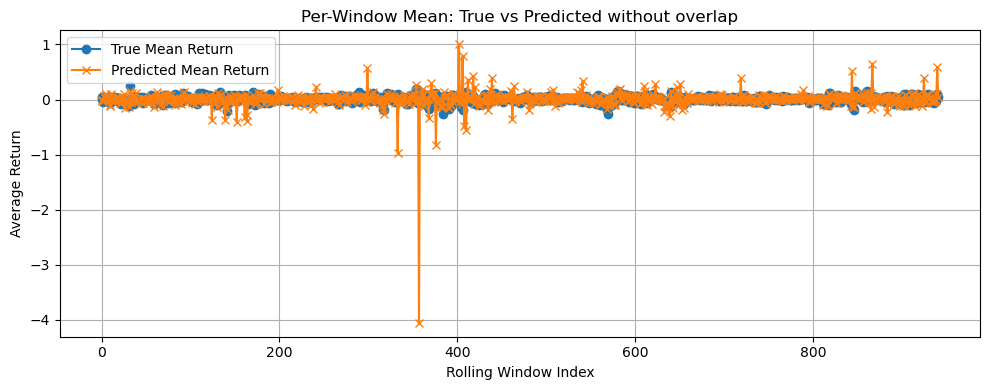

In [15]:
av_window(y_preds_no, y_tests_no, overlap=False)

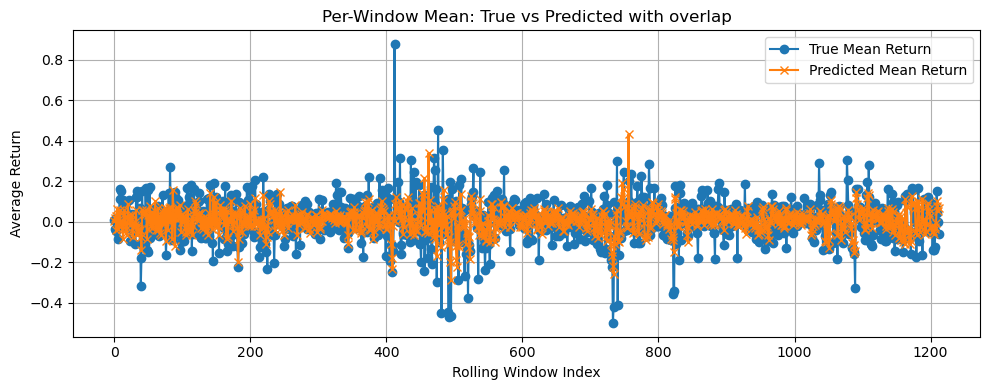

In [16]:
av_window(y_preds_o, y_tests_o, overlap=True)

In [17]:
def mse_window(y_preds, y_tests, overlap=False):

    mse_per_window = [
        mean_squared_error(np.ravel(y_true), np.ravel(y_pred))
        for y_true, y_pred in zip(y_tests, y_preds)
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(mse_per_window, label="Per-Window MSE", color='red', marker='s')
    plt.xlabel("Rolling Window Index")
    plt.ylabel("MSE")
    txt = "without" if not overlap else "with"
    plt.title("Prediction Error per Rolling Window "+txt+" overlap")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

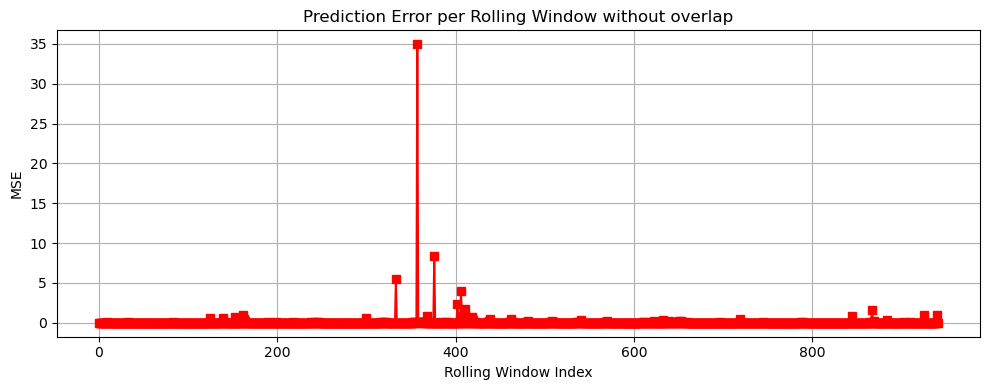

In [18]:
mse_window(y_preds_no, y_tests_no, overlap=False)

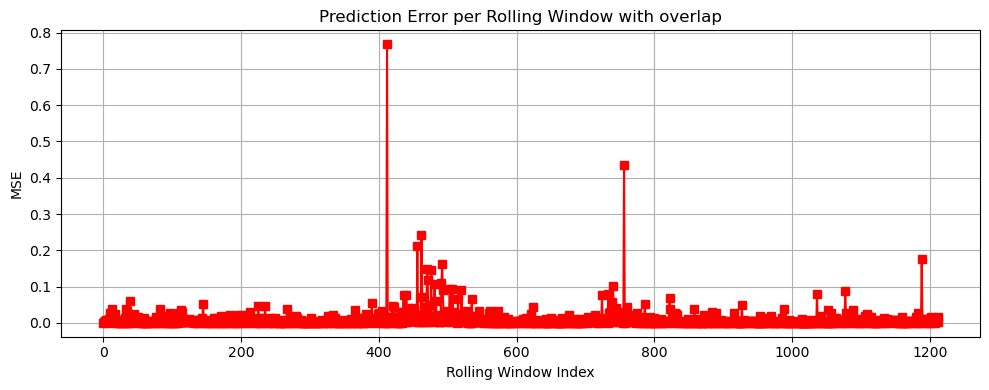

In [19]:
mse_window(y_preds_o, y_tests_o, overlap=True)

In [20]:
def bias_window(y_preds, y_tests, overlap=False):

    bias_per_window = [
        np.mean(np.ravel(y_pred) - np.ravel(y_true))
        for y_true, y_pred in zip(y_tests, y_preds)
    ]

    plt.figure(figsize=(10, 4))
    plt.plot(bias_per_window, label="Prediction Bias (Pred - True)", color='purple')
    plt.axhline(0, linestyle='--', color='black', linewidth=1)
    plt.xlabel("Rolling Window Index")
    plt.ylabel("Prediction Bias")
    txt = "without" if not overlap else "with"
    plt.title("Rolling Prediction Bias (Avg Error) "+txt+" overlap")
    plt.grid(True)
    plt.tight_layout()
    plt.legend()
    plt.show()


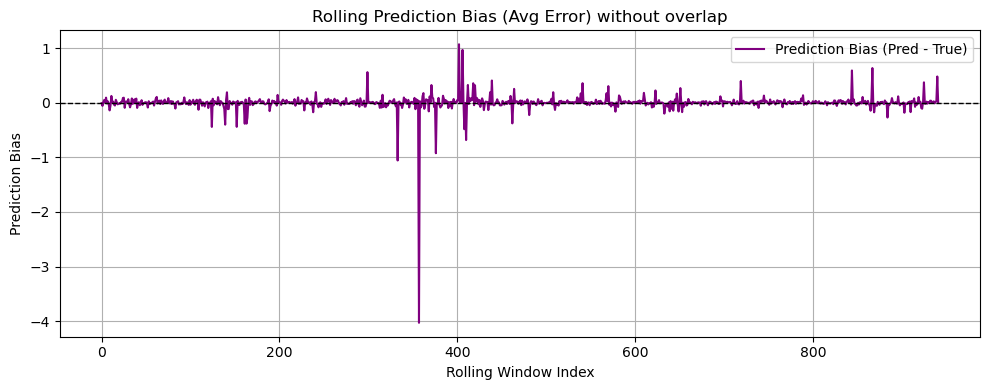

In [21]:
bias_window(y_preds_no, y_tests_no, overlap=False)

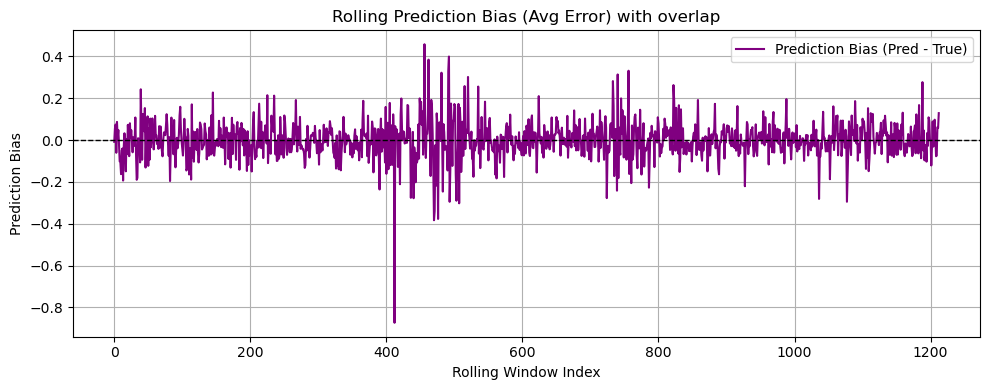

In [22]:
bias_window(y_preds_o, y_tests_o, overlap=True)

In [23]:
def plot_alpha_evolution(alphas, overlap=False):
    import matplotlib.pyplot as plt

    plt.figure(figsize=(10, 4))
    plt.plot(alphas, marker='o', label="Selected Alpha")
    plt.yscale('log')
    plt.xlabel("Rolling Window Index")
    plt.ylabel("Alpha (Regularization Strength)")
    txt = "without" if not overlap else "with"
    plt.title("Alpha Evolution per Rolling Window " + txt + " overlap")
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()


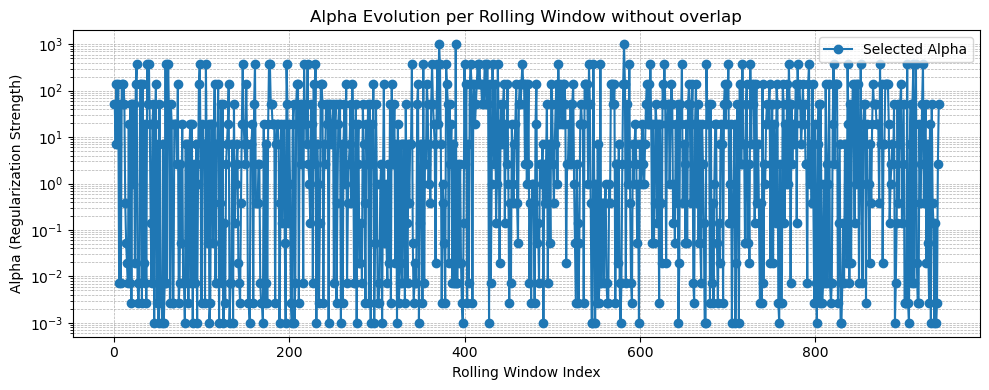

In [24]:
plot_alpha_evolution(alphas_non_overlap, overlap=False)


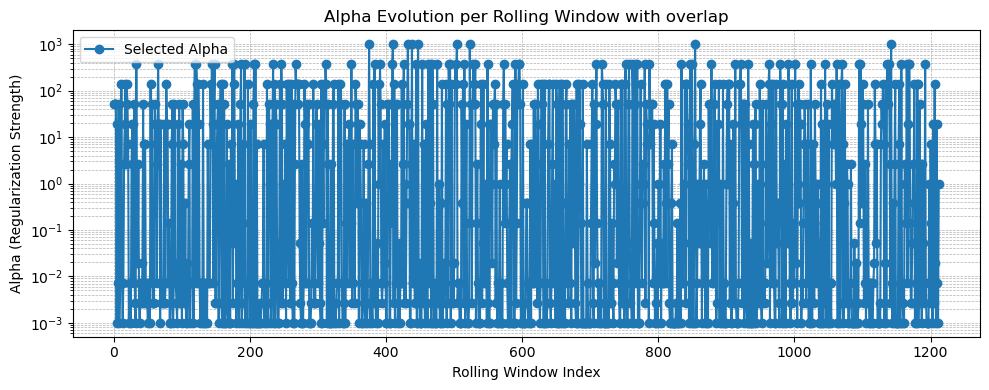

In [25]:
plot_alpha_evolution(alphas_overlap, overlap=True) 


Nested Cross Validation

In [26]:
def nested_cv_lasso(X, y, alphas, outer_splits=5, inner_splits=3, random_state=42):
    """
    Nested cross-validation for Lasso regression
    
    Parameters:
    -----------
    X : DataFrame
        Features
    y : Series
        Target values
    alphas : list
        List of alpha values to try
    outer_splits : int, default=5
        Number of outer CV splits
    inner_splits : int, default=3
        Number of inner CV splits
    random_state : int, default=42
        Random seed for reproducibility
        
    Returns:
    --------
    selected_alphas : list
        Selected alpha for each outer fold
    all_outer_scores : list
        MSE scores for each outer fold
    """
    
    outer_cv = KFold(n_splits=outer_splits, shuffle=True, random_state=random_state)
    all_outer_scores = []
    selected_alphas = []

    for train_idx, test_idx in outer_cv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # Inner CV to select best alpha
        inner_cv = KFold(n_splits=inner_splits, shuffle=True, random_state=random_state)
        inner_scores = []

        for alpha in alphas:
            fold_scores = []
            for inner_train_idx, val_idx in inner_cv.split(X_train):
                X_inner_train, X_val = X_train.iloc[inner_train_idx], X_train.iloc[val_idx]
                y_inner_train, y_val = y_train.iloc[inner_train_idx], y_train.iloc[val_idx]

                # Use sklearn's Lasso for stability
                model = Lasso(alpha=alpha, max_iter=10000, tol=1e-4)
                model.fit(X_inner_train, y_inner_train)
                y_pred = model.predict(X_val)
                score = mean_squared_error(y_val, y_pred)
                fold_scores.append(score)

            avg_score = np.mean(fold_scores)
            inner_scores.append((alpha, avg_score))

        # Select best alpha from inner CV
        best_alpha = min(inner_scores, key=lambda x: x[1])[0]
        selected_alphas.append(best_alpha)

        # Retrain on full training set with best alpha
        final_model = Lasso(alpha=best_alpha, max_iter=10000, tol=1e-4)
        final_model.fit(X_train, y_train)
        y_final_pred = final_model.predict(X_test)
        outer_score = mean_squared_error(y_test, y_final_pred)
        all_outer_scores.append(outer_score)

    return selected_alphas, all_outer_scores

In [27]:
alphas_grid = np.logspace(-4, 2, 20)
best_alphas, outer_mse_scores = nested_cv_lasso(X, y, alphas_grid)

print("Selected alphas per fold:", best_alphas)
print("Outer CV MSEs:", outer_mse_scores)
print("Avg MSE:", np.mean(outer_mse_scores))


Selected alphas per fold: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
Outer CV MSEs: [0.010136743144058779, 0.01046898868423692, 0.010173080983565118, 0.009901994842304635, 0.009636839625021144]
Avg MSE: 0.01006352945583732


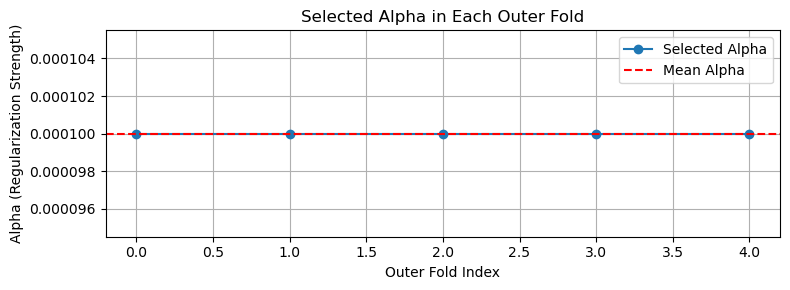

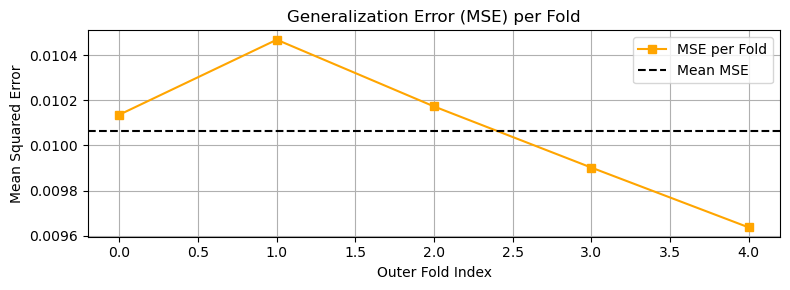

Nested CV Summary:
 → Selected alphas per fold: [0.0001, 0.0001, 0.0001, 0.0001, 0.0001]
 → Mean Alpha: 0.0001
 → Outer MSEs: [0.010136743144058779, 0.01046898868423692, 0.010173080983565118, 0.009901994842304635, 0.009636839625021144]
 → Avg MSE: 0.010064


In [28]:
import matplotlib.pyplot as plt

# Plot 1: Selected Alphas
plt.figure(figsize=(8, 3))
plt.plot(best_alphas, marker='o', linestyle='-', label='Selected Alpha')
plt.axhline(np.mean(best_alphas), color='red', linestyle='--', label='Mean Alpha')
plt.xlabel("Outer Fold Index")
plt.ylabel("Alpha (Regularization Strength)")
plt.title("Selected Alpha in Each Outer Fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 2: Outer Fold MSE
plt.figure(figsize=(8, 3))
plt.plot(outer_mse_scores, marker='s', color='orange', label='MSE per Fold')
plt.axhline(np.mean(outer_mse_scores), color='black', linestyle='--', label='Mean MSE')
plt.xlabel("Outer Fold Index")
plt.ylabel("Mean Squared Error")
plt.title("Generalization Error (MSE) per Fold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Text summary
print("Nested CV Summary:")
print(" → Selected alphas per fold:", best_alphas)
print(" → Mean Alpha: {:.4f}".format(np.mean(best_alphas)))
print(" → Outer MSEs:", outer_mse_scores)
print(" → Avg MSE: {:.6f}".format(np.mean(outer_mse_scores)))


Useage

In [29]:
# # Import necessary libraries
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import train_test_split, KFold
# from sklearn.linear_model import Lasso

# # Example usage
# X_unscaled = df.drop(columns='ret')
# X_unscaled = X_unscaled.apply(pd.to_numeric, errors='coerce')
# X = (X_unscaled-X_unscaled.mean(axis=0))/X_unscaled.std(axis=0)

# y = df['ret']
# y = y.apply(pd.to_numeric, errors='coerce')

# # Split data
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # Run Lasso with different feature subsets
# lasso_alphas_predictors(X_train, X_test, y_train, y_test)

# # Nested cross-validation
# # Run nested cross-validation with visualization
# alphas = np.logspace(-6, 2, 100)  # More granular alpha values
# selected_alphas, scores, coefficients = nested_cv_lasso(X, y, alphas)

# # Print summary statistics
# print("Selected alphas:", selected_alphas)
# print("Mean MSE:", np.mean(scores))
# print("Std MSE:", np.std(scores))

# # Analyze coefficient stability across folds
# coef_matrix = np.vstack(coefficients)
# mean_coefs = np.mean(coef_matrix, axis=0)
# std_coefs = np.std(coef_matrix, axis=0)

# # Plot mean coefficient values with error bars
# plt.figure(figsize=(15, 5))
# plt.errorbar(range(len(mean_coefs)), mean_coefs, yerr=std_coefs, fmt='o')
# plt.title('Mean Lasso Coefficients across Folds with Standard Deviation')
# plt.xlabel('Feature Index')
# plt.ylabel('Coefficient Value')
# plt.grid(True)
# plt.show()


# # Rolling window cross-validation
# alpha_results, y_tests, y_preds, scores = rolling_lasso_cv(X, y, alphas)